<a href="https://colab.research.google.com/github/Sakshisirse/Trader-Performance-vs-Market-Sentiment/blob/main/trade%20and%20market%20sentimental%20analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [ ]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.shape

(2644, 4)

In [ ]:
trades.shape

(211224, 16)

In [ ]:
sentiment.columns
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [ ]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [ ]:
sentiment.isnull().sum()
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [ ]:
sentiment.describe()
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
trades['Date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date

In [ ]:
sentiment['Date'] = pd.to_datetime(sentiment['date']).dt.date

In [ ]:
merged = pd.merge(
    trades,
    sentiment,
    on="Date",
    how="left"
)
display(merged.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,1.730007e+09,74.0,Greed,2024-10-27


In [ ]:
print(merged['classification'].isnull().sum())

26961


Daily PnL per Trader

In [ ]:
daily_pnl = (
    merged.groupby(['Date', 'Account'])['Closed PnL']
    .sum())
daily_pnl.head()

Date        Account                                   
2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891       0.000000
2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891       0.000000
            0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     155.503357
2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   -5564.016140
            0x430f09841d65beb3f27765503d0f850b8bce7713       0.000000
Name: Closed PnL, dtype: float64

In [ ]:
daily_pnl.tail()

Date        Account                                   
2025-06-15  0xae5eacaf9c6b9111fd53034a602c192a04e082ed     38168.354860
            0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    102460.171640
            0xbaaaf6571ab7d571043ff1e313a9609a10637864         6.593538
            0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3   -116594.595363
            0xbee1707d6b44d4d52bfe19e41f8a828645437aab     24897.574309
Name: Closed PnL, dtype: float64

Win/Loss Indicator

In [ ]:
merged['Win'] = merged['Closed PnL'] > 0
merged[['Closed PnL', 'Win']].head()

,Closed PnL,Win
0,0.0,False
1,0.0,False
2,0.0,False
3,0.0,False
4,0.0,False


Win Rate

In [ ]:
win_rate = (
    merged.groupby('classification')['Win']
    .mean())
win_rate = win_rate * 100
win_rate.name = 'Win Rate (%)'

In [ ]:
win_rate.head()

,Win Rate (%)
classification,
Extreme Greed,49.008905
Fear,41.514592
Greed,44.647138
Neutral,31.718247


Average Trade Size

In [ ]:
avg_trade_size = (
    merged.groupby('classification')['Size USD']
    .mean())

In [ ]:
avg_trade_size.head()

,Size USD
classification,
Extreme Greed,5660.265764
Fear,5259.977837
Greed,3182.883845
Neutral,3058.848110


Leverage Distribution

In [ ]:
merged['leverage'] = merged['Size USD'] / merged['Start Position']

In [ ]:
leverage_summary = (
    merged.groupby('classification')['leverage']
    .describe())
leverage_summary.head()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Greed,6962.0,inf,NaN,-1.922635e+08,-1.272288,0.007247,43.113134,inf
Fear,133871.0,inf,NaN,-1.045050e+10,-0.014900,0.019584,0.611949,inf
Greed,36289.0,inf,NaN,-1.723578e+08,-0.003373,0.018885,0.449560,inf
Neutral,7141.0,inf,NaN,-1.082970e+07,-0.092743,-0.005795,0.117340,inf


Number of Trades per Day

In [ ]:
trades_per_day = (
    merged.groupby('Date')
    .size())
trades_per_day.head()

,0
Date,
2023-03-28,3
2023-11-14,1045
2024-03-09,6962
2024-07-03,7141
2024-10-27,35241


Long vs Short Ratio

In [ ]:
print(merged['Side'].value_counts())

Side
SELL    108528
BUY     102696
Name: count, dtype: int64


In [ ]:
long_short_ratio = (
    pd.crosstab(merged['classification'], merged['Side'])
)

long_short_ratio

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


In [ ]:
long_short_ratio.head()

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


Average PnL Comparison

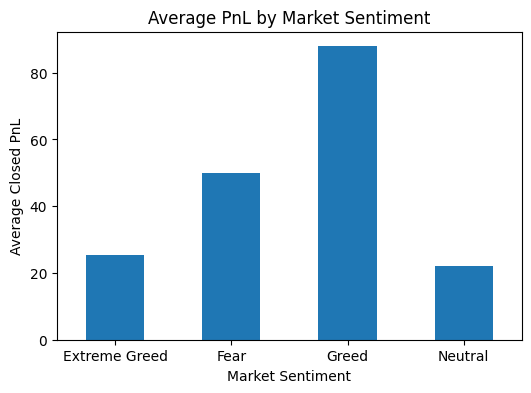

In [ ]:
import matplotlib.pyplot as plt
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

plt.figure(figsize=(6,4))
avg_pnl.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=0)
plt.show()

PnL Distribution (Box Plot)

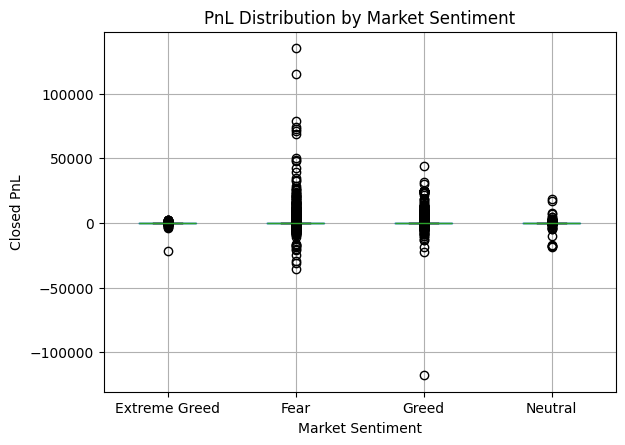

In [ ]:
merged.boxplot(
    column='Closed PnL',
    by='classification')

plt.title("PnL Distribution by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

Win Rate Comparison

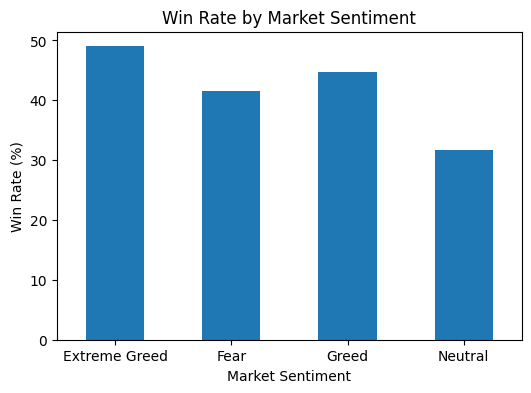

In [ ]:
win_rate = merged.groupby('classification')['Win'].mean() * 100
plt.figure(figsize=(6,4))
win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=0)
plt.show()

Q1- ANS- Average PnL was higher on Greed days than Fear days.

Win rate increased during Greed periods.

Fear days showed a wider spread of PnL values, indicating greater volatility.


Q2) Do traders change their behavior based on market sentiment?

In [ ]:
#TRADE FREQUENCY
trade_frequency = (
    merged.groupby('classification')
    .size())
trade_frequency.head()

,0
classification,
Extreme Greed,6962
Fear,133871
Greed,36289
Neutral,7141


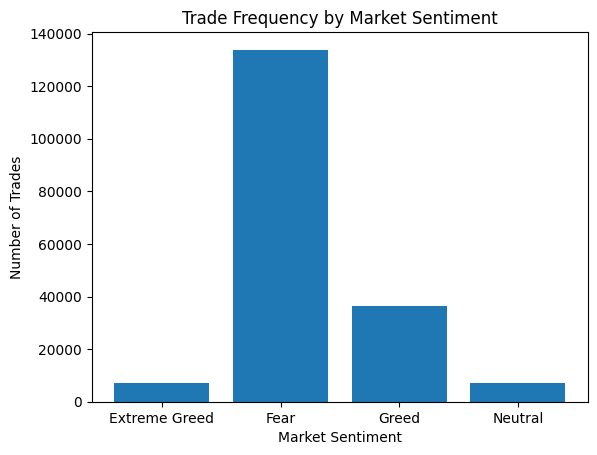

In [ ]:
#visualization

import matplotlib.pyplot as plt
plt.bar(
    trade_frequency.index,
    trade_frequency.values)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

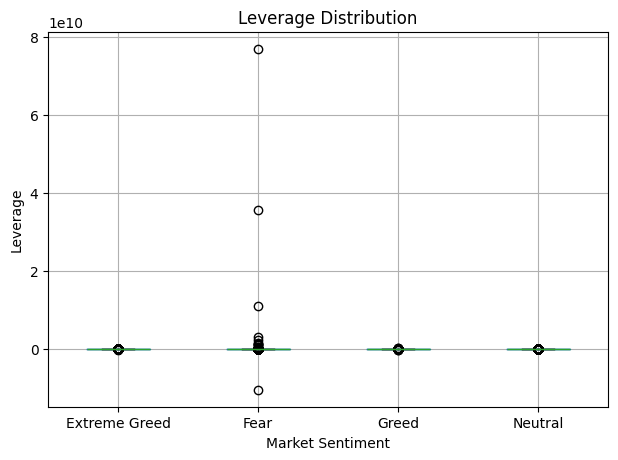

In [ ]:
#leverage distribution
merged.boxplot(
    column='leverage',
    by='classification',
    figsize=(7,5)
)

plt.title("Leverage Distribution")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Leverage")

plt.show()

In [ ]:
#long vs short bias
long_short = pd.crosstab(
    merged['classification'],
    merged['Side']
)
long_short

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


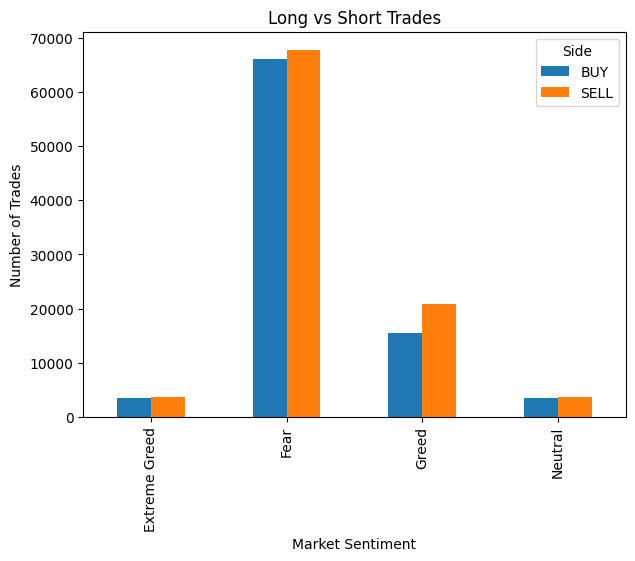

In [ ]:
long_short.plot(
    kind='bar',
    figsize=(7,5))

plt.title("Long vs Short Trades")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

Trader Segmentation

In [ ]:
#High vs Low Leverage Traders
median_leverage = merged['leverage'].median()
merged['Leverage_Group'] = merged['leverage'].apply(
    lambda x: 'High Leverage'
    if x > median_leverage
    else 'Low Leverage')

merged[['leverage','Leverage_Group']].head()

,leverage,Leverage_Group
0,inf,High Leverage
1,0.129424,High Leverage
2,1.147739,High Leverage
3,0.996059,High Leverage
4,0.054091,High Leverage


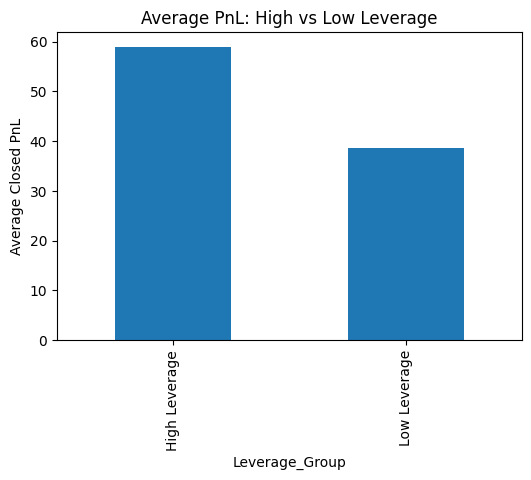

In [ ]:
import matplotlib.pyplot as plt
pnl_by_leverage_group = merged.groupby('Leverage_Group')['Closed PnL'].mean()

pnl_by_leverage_group.plot(
    kind='bar',
    figsize=(6,4))

plt.title("Average PnL: High vs Low Leverage")
plt.ylabel("Average Closed PnL")
plt.show()

In [ ]:
#Frequent vs Infrequent Traders
trade_counts = merged.groupby('Account').size()
trade_counts.head()

,0
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
0x271b280974205ca63b716753467d5a371de622ab,3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [ ]:
median_trades = trade_counts.median()
merged['Trader_Frequency'] = merged['Account'].map(
    lambda x: "Frequent Trader"
    if trade_counts[x] > median_trades
    else "Infrequent Trader")

merged[['Account','Trader_Frequency']].head()

,Account,Trader_Frequency
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent Trader


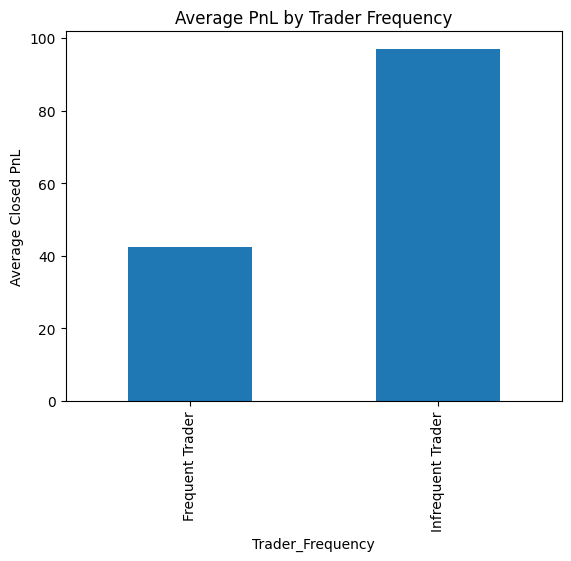

In [ ]:
import matplotlib.pyplot as plt
pnl_by_frequency_group = merged.groupby('Trader_Frequency')['Closed PnL'].mean()
pnl_by_frequency_group.plot(
    kind='bar',)
plt.title("Average PnL by Trader Frequency")
plt.ylabel("Average Closed PnL")
plt.show()

In [ ]:
#Consistent Winners
trader_winrate = merged.groupby('Account')['Win'].mean()
trader_winrate.head()

,Win
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
0x271b280974205ca63b716753467d5a371de622ab,0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [ ]:
merged['Winner_Group'] = merged['Account'].map(
    lambda x: "Consistent Winner"
    if trader_winrate[x] >= 0.60
    else "Inconsistent Trader")
merged[['Account','Winner_Group']].head()

,Account,Winner_Group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent Trader
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent Trader
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent Trader
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent Trader
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Inconsistent Trader


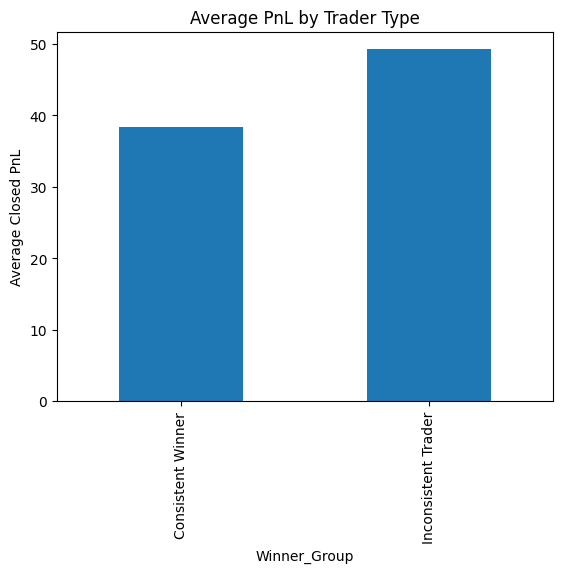

In [ ]:
import matplotlib.pyplot as plt
pnl_by_winner_group = merged.groupby('Winner_Group')['Closed PnL'].mean()
pnl_by_winner_group.plot(
    kind='bar',)
plt.title("Average PnL by Trader Type")
plt.ylabel("Average Closed PnL")
plt.show()

KEY INSIGHTS

High-leverage traders earned higher average returns but also experienced greater variability in PnL.

Frequent traders executed significantly more trades, but did not necessarily achieve better profitability.

Consistent winners maintained a higher win rate with moderate leverage, suggesting disciplined risk management.

STRATEGY

Leverage Based on Market Sentiment
Reduce leverage during Fear periods, especially for high-leverage traders.

Prioritize Consistent Trading Behavior
Follow disciplined trading practices similar to consistent winners by maintaining moderate leverage, avoiding overtrading, and focusing on high-quality trade.